# 🧩 Archetipo specifico — dal meta al deck.csv

Questo notebook parte da un **archetipo** individuato in
[`04_deck_vs_skill_analysis.ipynb`](04_deck_vs_skill_analysis.ipynb) e risponde alla domanda:

> **Se voglio giocare questo mazzo, quali carte metto?**

Per farlo:

1. Isola tutte le istanze (partite) di un archetipo scelto.
2. Misura quanto spesso ogni carta compare nelle liste reali → separa le carte **core**
   (quasi sempre incluse) dalle carte **flex/libere** (variano da pilota a pilota).
3. Propone **due versioni** di mazzo pronte da 60 carte:
   - la build **esatta più giocata** in assoluto;
   - un mazzo **consensus**, costruito dalle carte core + il riempimento flex più comune.
4. Esporta entrambe in formato `deck.csv` (lo stesso formato letto da `agents/*/main.py`).
5. Mostra il mazzo consensus come un'unica immagine, recuperando le art delle carte online
   con lo stesso schema URL usato da [`view_replays/replay_render.py`](../view_replays/replay_render.py)
   per il visualizzatore dei replay (CDN di limitlesstcg.com, da `Expansion` + `Collection No.`).

> Serve `meta_utils` e `competiotion_scraper` (già nella cartella). Se non c'è un DB reale il
> notebook ricade sul DB **dimostrativo** (dati sintetici), come in `04_deck_vs_skill_analysis.ipynb`.
> Il recupero delle immagini richiede una connessione internet: se non è disponibile (o una carta
> non si trova sul CDN), al suo posto viene mostrato un riquadro con il nome della carta.

In [2]:
import sys, sqlite3, warnings, math, re, difflib
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
import meta_utils as mu
import competiotion_scraper as scr

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10, "figure.autolayout": True})
PAL = plt.get_cmap("tab10").colors

def save(fig, name):
    fig.savefig(mu.FIG_DIR / f"05_{name}.png", bbox_inches="tight", dpi=130)

# --- card pool robusto: il CSV puo' stare in doc/ oppure in view_replays/card_data ----
def _find_card_csv():
    cands = [mu.EN_CARD_CSV,
             mu.ROOT / "view_replays" / "card_data" / "EN_Card_Data.csv",
             mu.ROOT / "doc" / "pokemon-tcg-ai-battle" / "EN_Card_Data.csv"]
    for p in cands:
        if Path(p).exists():
            return Path(p)
    raise FileNotFoundError("EN_Card_Data.csv non trovato (cercato in doc/ e view_replays/card_data/)")

CARD_CSV = _find_card_csv()
pool = mu.cards_unique(mu.load_cards(CARD_CSV)).set_index("Card ID")
CARD_NAME = pool["Card Name"].to_dict()
print("Card pool:", len(pool), "carte da", CARD_CSV.relative_to(mu.ROOT))

# cards_unique() (condivisa con 04) non porta il numero di collezione (serve per le immagini)
# ne' la distinzione energia-di-base/speciale (serve per le regole di legalita' del mazzo):
# li aggiungiamo qui dal CSV grezzo, prendendo la prima riga per ciascun Card ID.
_first = mu.load_cards(CARD_CSV).sort_values("Card ID").groupby("Card ID").first()
pool["Collection No."] = _first["Collection No."]
pool["is_basic_energy"] = _first["subtype"] == "Basic Energy"
pool["is_basic_pokemon"] = pool["is_pokemon"] & _first["subtype"].str.contains("Basic", na=False)

# Lo scraper scrive i nomi carta leggendo un CSV che qui potrebbe non esistere: gli passo
# la mappa gia' pronta cosi' scrape()/save_episode lanciati da qui non vanno in errore.
scr._CARD_NAMES = CARD_NAME

Card pool: 1267 carte da doc\pokemon-tcg-ai-battle\EN_Card_Data.csv


## 0. Carica il DB delle partite

Stessa logica di `04_deck_vs_skill_analysis.ipynb`: usa il DB reale se presente
(`ptcg_data/matches.db`), altrimenti genera un piccolo DB dimostrativo così il notebook resta
eseguibile anche senza aver lanciato lo scraper.

In [3]:
def build_demo_db(path, n_matches=140, seed=7):
    """DB sintetico con la struttura reale: 8 team su 4 archetipi (2 piloti ciascuno)."""
    rng = np.random.RandomState(seed)
    if Path(path).exists():
        Path(path).unlink()
    poke = pool[pool["is_pokemon"]].copy()
    key_pool = poke.sort_values(["is_mega", "is_ex", "hp_num"], ascending=False).head(40).index.tolist()
    fill_pool = pool.index.tolist()
    rng.shuffle(key_pool)
    archs = {}
    for i in range(4):
        keys = key_pool[2 * i:2 * i + 2]
        archs[f"arch{i}"] = keys + list(rng.choice(fill_pool, 10, replace=False))
    teams = {f"team{t}": (f"arch{t % 4}", 0.62 - 0.09 * (t // 4)) for t in range(8)}
    conn = scr.get_db(path)
    names = list(teams)
    for m in range(n_matches):
        a0, a1 = rng.choice(names, 2, replace=False)
        s0, s1 = teams[a0][1], teams[a1][1]
        w = 0 if rng.rand() < s0 / (s0 + s1) else 1
        parsed = {"episode_id": f"demo-{m:04d}", "agents": [a0, a1],
                  "rewards": [1.0, -1.0] if w == 0 else [-1.0, 1.0], "winner": w,
                  "n_steps": int(rng.randint(30, 120)), "n_plays": 0,
                  "deck_player0": [], "deck_player1": [], "play_sequence": []}
        for pidx, ag in ((0, a0), (1, a1)):
            cards = archs[teams[ag][0]]
            parsed[f"deck_player{pidx}"] = list(rng.choice(cards, 60))
        scr.save_episode(conn, parsed)
    conn.close()
    return path

def pick_db():
    real, demo = scr.DB_PATH, scr.DEMO_DB_PATH
    if real.exists():
        n = sqlite3.connect(real).execute("select count(*) from matches").fetchone()[0]
        if n > 0:
            return real, False
    print("Nessun DB reale: genero un DB dimostrativo (dati sintetici)...")
    build_demo_db(demo)
    return demo, True

DB_PATH, IS_DEMO = pick_db()
conn = sqlite3.connect(DB_PATH)
matches = pd.read_sql("select * from matches", conn)
decks   = pd.read_sql("select * from match_decks", conn)

banner = ("DATI DIMOSTRATIVI (sintetici) - popola il DB con lo scraper per i numeri reali."
          if IS_DEMO else "Dati reali dal DB delle partite.")
print("="*88); print(banner)
print("DB:", DB_PATH.name, "| partite:", len(matches), "| mazzi:", decks["episode_id"].nunique())
print("="*88)

Dati reali dal DB delle partite.
DB: matches.db | partite: 8624 | mazzi: 8624


## 1. Archetipi dai mazzi (come in 04)

Stessa euristica di `04_deck_vs_skill_analysis.ipynb`: ogni mazzo è etichettato dalle sue
Pokémon chiave (Mega/ex/HP più alti), così i risultati restano coerenti tra i due notebook —
puoi copiare un nome di archetipo dall'output di 04 e userà la stessa etichetta qui.

In [4]:
TOP_KEY_POKEMON = 2   # quante Pokemon chiave nel nome dell'archetipo

def deck_signature(card_copies: dict) -> str:
    """Etichetta un mazzo dalle sue Pokemon piu' rilevanti (Mega/ex/HP)."""
    poke = []
    other = []
    for cid, cp in card_copies.items():
        if cid not in pool.index:
            continue
        r = pool.loc[cid]
        entry = (bool(r["is_mega"]), bool(r["is_ex"]), float(r["hp_num"] or 0), int(cp),
                 str(r["Card Name"]))
        (poke if bool(r["is_pokemon"]) else other).append(entry)
    src = poke or other
    if not src:
        return "(non classificato)"
    src.sort(reverse=True)   # Mega > ex > HP > copie
    names = []
    for *_, nm in src:
        if nm not in names:
            names.append(nm)
        if len(names) >= TOP_KEY_POKEMON:
            break
    return " + ".join(names)

# firma per ogni (episodio, giocatore)
sig_map = {}
for (ep, pidx), grp in decks.groupby(["episode_id", "player_idx"]):
    sig_map[(ep, int(pidx))] = deck_signature(dict(zip(grp["card_id"], grp["copies"])))

# tabella "lunga": una riga per giocatore-partita
recs = []
for _, m in matches.iterrows():
    ep, w = m["episode_id"], m["winner_idx"]
    ag = [m["agent0"], m["agent1"]]
    ar = [sig_map.get((ep, 0), "(non classificato)"), sig_map.get((ep, 1), "(non classificato)")]
    for s in (0, 1):
        recs.append({
            "episode_id": ep, "side": s, "agent": ag[s], "archetype": ar[s],
            "won": np.nan if pd.isna(w) else int(w == s),
        })
games = pd.DataFrame(recs)
decided = games.dropna(subset=["won"]).copy()
decided["won"] = decided["won"].astype(int)

print(f"Archetipi distinti: {games['archetype'].nunique()} | "
      f"partite decise: {len(decided)//2} | pilotati da {games['agent'].nunique()} team")

pop = (games.groupby("archetype")
       .agg(partite=("episode_id", "size"), piloti=("agent", "nunique"))
       .reset_index())
pop["quota_%"] = (100 * pop["partite"] / pop["partite"].sum()).round(1)
pop = pop.sort_values("partite", ascending=False).reset_index(drop=True)
print("\nArchetipi piu' giocati (per scegliere quale analizzare qui sotto):")
pop.head(20)

Archetipi distinti: 154 | partite decise: 8614 | pilotati da 1346 team

Archetipi piu' giocati (per scegliere quale analizzare qui sotto):


,archetype,partite,piloti,quota_%
0,Marnie's Grimmsnarl ex + Munkidori,6934,200,40.2
1,Fezandipiti ex + Alakazam,3948,248,22.9
2,Team Rocket's Mewtwo ex + Team Rocket's Spidops,1324,54,7.7
3,Cynthia's Garchomp ex + Cynthia's Roserade,1133,58,6.6
4,Mega Kangaskhan ex + Crustle,864,75,5.0
5,Dragapult ex + Fezandipiti ex,322,31,1.9
6,Mega Kangaskhan ex + Cornerstone Mask Ogerpon ex,200,5,1.2
7,Mega Lucario ex + Solrock,192,18,1.1
8,Mega Kangaskhan ex + Raging Bolt ex,183,2,1.1
9,Archaludon ex + Cinderace,159,100,0.9


## 2. Scegli l'archetipo da analizzare

**Modifica `ARCHETYPE_QUERY` qui sotto** — puoi incollare un nome esatto dalla tabella qui sopra
(o dall'output di `04_deck_vs_skill_analysis.ipynb`), oppure una sottostringa case-insensitive
(es. `"Lucario"` invece del nome completo): se corrisponde a più archetipi viene scelto quello
più giocato e vengono elencate le alternative.

Di default è impostato sull'archetipo più popolare, così il notebook gira anche senza modifiche.

In [14]:
# ==== PARAMETRO: modifica qui l'archetipo da analizzare ====
ARCHETYPE_QUERY = "Cynthia's Garchomp ex + Cynthia's Roserade"   # <- sostituisci con un nome o una sottostringa
# =============================================================

def resolve_archetype(query, pop_df):
    names = pop_df["archetype"].tolist()
    if query in names:
        return query
    ql = str(query).lower()
    hits = [n for n in names if ql in n.lower()]
    if len(hits) == 1:
        return hits[0]
    if len(hits) > 1:
        best = pop_df[pop_df["archetype"].isin(hits)].sort_values("partite", ascending=False)
        print(f"Piu' di un archetipo corrisponde a {query!r} -- prendo il piu' giocato:")
        display(best[["archetype", "partite", "piloti"]])
        return best.iloc[0]["archetype"]
    close = difflib.get_close_matches(str(query), names, n=5)
    raise ValueError(f"Nessun archetipo corrisponde a {query!r}. Forse intendevi: {close}")

ARCHETYPE = resolve_archetype(ARCHETYPE_QUERY, pop)
print("\n>> Archetipo selezionato:", ARCHETYPE)


>> Archetipo selezionato: Cynthia's Garchomp ex + Cynthia's Roserade


## 3. Istanze di questo mazzo

Tutte le partite in cui l'archetipo scelto è stato giocato, per team pilota e (dove nota) winrate
del pilota. Team con poche partite hanno stime di winrate rumorose — guarda anche `partite`.

In [15]:
inst = games[games["archetype"] == ARCHETYPE].copy()
n_instances = len(inst)
if n_instances == 0:
    raise ValueError(f"Nessuna istanza per l'archetipo {ARCHETYPE!r}.")

dec_inst = decided[decided["archetype"] == ARCHETYPE]
by_team = inst.groupby("agent").agg(partite=("episode_id", "size"))
wr_by_team = dec_inst.groupby("agent")["won"].agg(winrate="mean")
riepilogo = by_team.join(wr_by_team, how="left").sort_values("partite", ascending=False)
riepilogo["winrate_%"] = (100 * riepilogo["winrate"]).round(1)

print(f"Istanze di '{ARCHETYPE}': {n_instances} partite, {inst['agent'].nunique()} team")
display(riepilogo[["partite", "winrate_%"]])

Istanze di 'Cynthia's Garchomp ex + Cynthia's Roserade': 1133 partite, 58 team


,partite,winrate_%
agent,,
Roman Stupin,212,59.4
junlee789,193,57.5
bono,172,61.6
junseo lee,128,62.5
Yudai Ueno,117,47.0
Budew,72,68.1
Orin,70,65.7
Marshall Maximizer,27,63.0
Phil_Hellmuth,16,31.2


## 4. Frequenza delle carte: cosa è "core" e cosa è libero

Per ogni carta vista in una decklist di questo archetipo calcoliamo:

- **`inclusion_pct`** — in che percentuale delle istanze compare (almeno 1 copia);
- **`mode_copies`** — il numero di copie più comune quando è inclusa.

Una carta con `inclusion_pct` alto (default: **soglia core = 85%**) è uno **staple**: quasi ogni
pilota la gioca, indipendentemente da chi guida il mazzo. Sotto la soglia è una scelta **libera/flex**
— lo slot esiste, ma i piloti lo riempiono in modo diverso (tech card, adattamenti al meta, gusto
personale).

Carte distinte viste in questo archetipo: 36 | core (>= 85%): 20


,card_id,card_name,n_decks,inclusion_pct,mode_copies,core
0,6,Basic {F} Energy,1133,100%,5,True
1,20,Rock Fighting Energy,1133,100%,4,True
2,341,Cynthia's Roselia,1133,100%,4,True
3,342,Cynthia's Roserade,1133,100%,3,True
4,1227,Lillie's Determination,1133,100%,4,True
5,379,Cynthia's Gible,1133,100%,4,True
6,380,Cynthia's Gabite,1133,100%,4,True
7,381,Cynthia's Garchomp ex,1133,100%,3,True
8,1086,Buddy-Buddy Poffin,1133,100%,4,True
9,1173,Cynthia's Power Weight,1133,100%,3,True


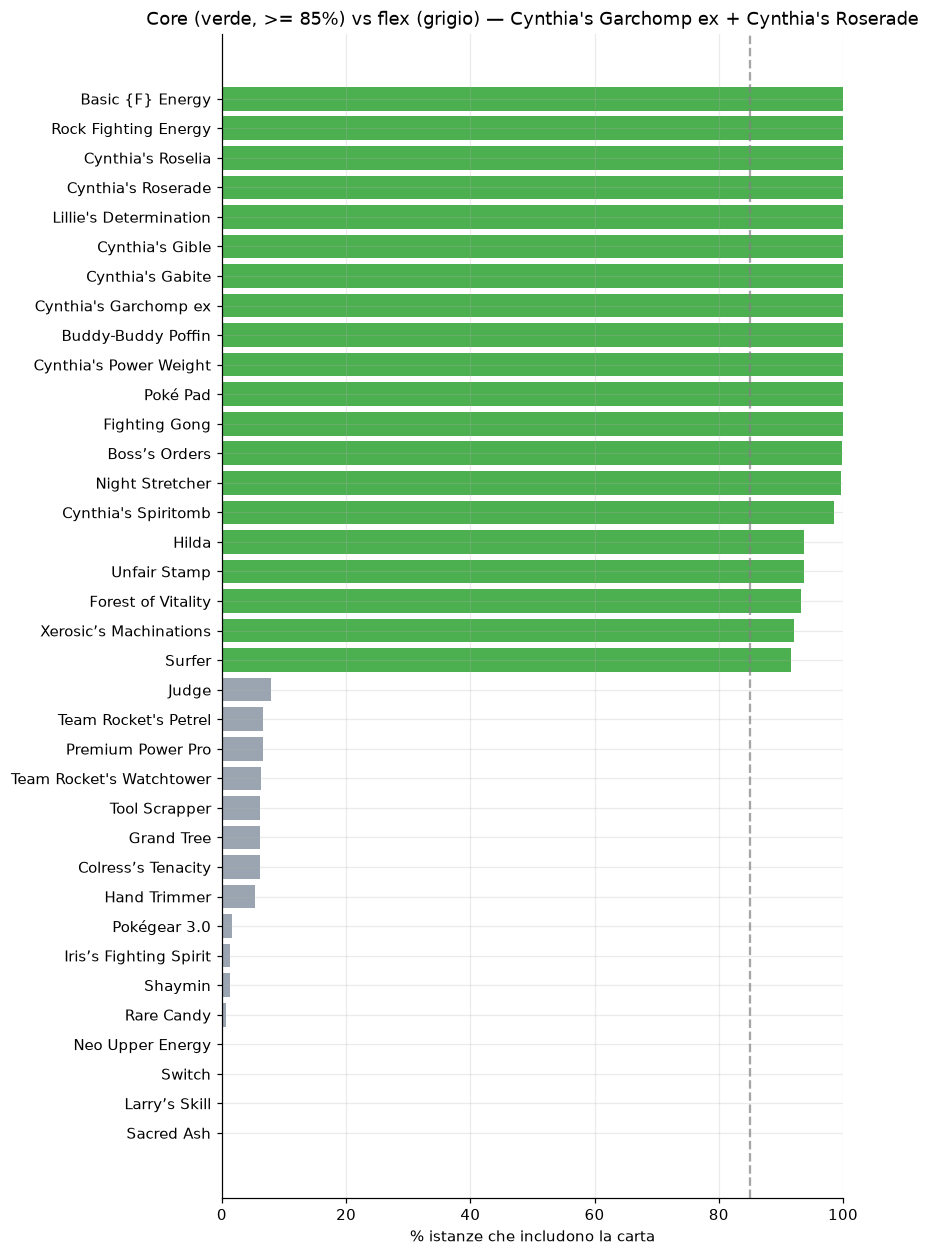

In [16]:
CORE_THRESHOLD = 0.85

inst_df = inst[["episode_id", "side"]].rename(columns={"side": "player_idx"}).drop_duplicates()
deck_rows = decks.merge(inst_df, on=["episode_id", "player_idx"], how="inner")

freq = (deck_rows.groupby("card_id")["copies"]
        .agg(n_decks="size", avg_copies_incl="mean", mode_copies=lambda s: s.mode().iat[0])
        .reset_index())
freq["inclusion_pct"] = freq["n_decks"] / n_instances
freq["card_name"] = freq["card_id"].map(CARD_NAME)
freq["core"] = freq["inclusion_pct"] >= CORE_THRESHOLD
freq = freq.sort_values("inclusion_pct", ascending=False).reset_index(drop=True)

print(f"Carte distinte viste in questo archetipo: {len(freq)} | "
      f"core (>= {CORE_THRESHOLD:.0%}): {int(freq['core'].sum())}")
display(freq[["card_id", "card_name", "n_decks", "inclusion_pct", "mode_copies", "core"]]
        .style.format({"inclusion_pct": "{:.0%}"}))

# alcuni nomi carta si ripetono su piu' ristampe/set (Card ID diversi): disambigua le etichette
# del grafico aggiungendo l'id solo dove serve, cosi' non si sovrappongono due barre sullo stesso tick
_dupe_names = set(freq["card_name"][freq["card_name"].duplicated(keep=False)])
freq["label"] = [f"{n} (#{c})" if n in _dupe_names else n for n, c in zip(freq["card_name"], freq["card_id"])]

t = freq.iloc[::-1]
colors = ["#4caf50" if c else "#9aa5b1" for c in t["core"]]
fig, ax = plt.subplots(figsize=(8, max(3, .32 * len(t))))
ax.barh(t["label"], 100 * t["inclusion_pct"], color=colors)
ax.axvline(100 * CORE_THRESHOLD, ls="--", color="grey", alpha=.7)
ax.set_xlim(0, 100); ax.set_xlabel("% istanze che includono la carta")
ax.set_title(f"Core (verde, >= {CORE_THRESHOLD:.0%}) vs flex (grigio) — {ARCHETYPE}")
save(fig, "card_inclusion"); plt.show()

## 5. Proposta di mazzo (versioni pronte per `deck.csv`)

Due modi diversi di rispondere a "che mazzo gioco":

- **Versione A — build esatta più giocata**: la combinazione precisa di 60 carte che ricorre più
  spesso, cioè la lista reale di un pilota (o di più piloti che convergono sulla stessa build).
- **Versione B — mazzo consensus**: le carte core alla loro copia più comune, riempendo gli slot
  restanti con le carte flex più incluse — un "meta-mazzo" che riassume l'archetipo anche se
  nessun singolo pilota ha giocato esattamente questa lista.

Entrambe rispettano le regole di costruzione mazzo (max 4 copie per carta non-energia-di-base,
massimo 1 ACE SPEC, energie di base illimitate) e vengono validate prima dell'export.

In [17]:
def deck_key(g):
    return tuple(sorted(zip(g["card_id"].tolist(), g["copies"].tolist())))

build_sig = deck_rows.groupby(["episode_id", "player_idx"]).apply(deck_key, include_groups=False)
build_counts = build_sig.value_counts()
top_key, top_n = build_counts.index[0], int(build_counts.iloc[0])
version_a = dict(top_key)

print(f"Build esatta piu' comune: {top_n}/{n_instances} istanze ({100*top_n/n_instances:.0f}%) "
      f"su {build_counts.shape[0]} varianti distinte in totale")

Build esatta piu' comune: 1024/1133 istanze (90%) su 15 varianti distinte in totale


In [18]:
def cap_for(cid):
    """Copie massime per carta: illimitate per l'energia di base, altrimenti 4."""
    return 999 if (cid in pool.index and bool(pool.loc[cid, "is_basic_energy"])) else 4

def is_ace_spec(cid):
    return bool(pool.loc[cid, "is_ace_spec"]) if cid in pool.index else False

def build_consensus_deck(freq_df, target=60):
    deck, total, ace_used = {}, 0, False
    # 1) core alla copia piu' comune
    for _, r in freq_df[freq_df["core"]].iterrows():
        cid = int(r["card_id"])
        if is_ace_spec(cid) and ace_used:
            continue
        copies = 1 if is_ace_spec(cid) else min(int(round(r["mode_copies"])), cap_for(cid))
        copies = min(copies, target - total)
        if copies <= 0:
            continue
        deck[cid] = copies; total += copies
        ace_used = ace_used or is_ace_spec(cid)
    # 2) riempi gli slot liberi con le carte flex piu' incluse
    for _, r in freq_df[~freq_df["core"]].iterrows():
        if total >= target:
            break
        cid = int(r["card_id"])
        if is_ace_spec(cid) and ace_used:
            continue
        want = max(int(round(r["mode_copies"])), 1)
        copies = min(want, cap_for(cid), target - total)
        if copies <= 0:
            continue
        deck[cid] = deck.get(cid, 0) + copies; total += copies
        ace_used = ace_used or is_ace_spec(cid)
    # 3) se il campione non basta a coprire 60 carte, completa con l'energia di base piu' vista
    if total < target:
        energies = freq_df[freq_df["card_id"].map(
            lambda c: pool.loc[c, "is_basic_energy"] if c in pool.index else False)]
        energies = energies.sort_values("inclusion_pct", ascending=False)
        top_energy = int(energies.iloc[0]["card_id"]) if len(energies) else int(pool[pool["is_basic_energy"]].index[0])
        deck[top_energy] = deck.get(top_energy, 0) + (target - total)
        total = target
    return deck, total

version_b, total_b = build_consensus_deck(freq)
print(f"Mazzo consensus: {total_b} carte, {len(version_b)} carte distinte")

Mazzo consensus: 60 carte, 20 carte distinte


In [19]:
def validate_deck(deck):
    """Controlli di legalita' base: 60 carte, max 4 copie (tranne energia di base), <=1 ACE SPEC,
    almeno un Pokemon Base (regole richiamate anche da cg.game.battle_start)."""
    issues = []
    total = sum(deck.values())
    if total != 60:
        issues.append(f"totale carte = {total}, deve essere 60")
    for cid, cp in deck.items():
        if cid in pool.index and not pool.loc[cid, "is_basic_energy"] and cp > 4:
            issues.append(f"{CARD_NAME.get(cid, cid)}: {cp} copie (max 4)")
    aces = [c for c in deck if is_ace_spec(c)]
    if len(aces) > 1:
        issues.append(f"piu' di 1 ACE SPEC: {[CARD_NAME.get(c, c) for c in aces]}")
    if not any(pool.loc[c, "is_basic_pokemon"] for c in deck if c in pool.index):
        issues.append("nessun Pokemon Base nel mazzo")
    return issues

def deck_table(deck):
    # alcuni nomi si ripetono su piu' Card ID (ristampe): disambigua solo quelli in comune nel mazzo
    names = [CARD_NAME.get(cid, f"#{cid}") for cid in deck]
    dupe_names = {n for n in names if names.count(n) > 1}
    rows = []
    for cid, cp in deck.items():
        r = pool.loc[cid] if cid in pool.index else None
        if r is not None and bool(r["is_energy"]):
            cat = "Energia"
        elif r is not None and bool(r["is_trainer"]):
            cat = "Trainer"
        elif r is not None and bool(r["is_pokemon"]):
            cat = "Pokemon"
        else:
            cat = "Trainer"
        nome = CARD_NAME.get(cid, f"#{cid}")
        if nome in dupe_names:
            nome = f"{nome} (#{cid})"
        rows.append({"card_id": cid, "nome": nome, "categoria": cat, "copie": cp})
    return (pd.DataFrame(rows)
            .sort_values(["categoria", "copie", "nome"], ascending=[True, False, True])
            .reset_index(drop=True))

for name, d in [("A - piu' giocata", version_a), ("B - consensus", version_b)]:
    issues = validate_deck(d)
    print(f"Validazione {name}: {'OK' if not issues else issues}")

print("\n--- Versione A: build esatta piu' giocata ---")
display(deck_table(version_a))
print("\n--- Versione B: mazzo consensus ---")
display(deck_table(version_b))

Validazione A - piu' giocata: OK
Validazione B - consensus: OK

--- Versione A: build esatta piu' giocata ---


,card_id,nome,categoria,copie
0,6,Basic {F} Energy,Energia,5
1,20,Rock Fighting Energy,Energia,4
2,380,Cynthia's Gabite,Pokemon,4
3,379,Cynthia's Gible,Pokemon,4
4,341,Cynthia's Roselia,Pokemon,4
5,381,Cynthia's Garchomp ex,Pokemon,3
6,342,Cynthia's Roserade,Pokemon,3
7,387,Cynthia's Spiritomb,Pokemon,2
8,1086,Buddy-Buddy Poffin,Trainer,4
9,1142,Fighting Gong,Trainer,4



--- Versione B: mazzo consensus ---


,card_id,nome,categoria,copie
0,6,Basic {F} Energy,Energia,5
1,20,Rock Fighting Energy,Energia,4
2,380,Cynthia's Gabite,Pokemon,4
3,379,Cynthia's Gible,Pokemon,4
4,341,Cynthia's Roselia,Pokemon,4
5,381,Cynthia's Garchomp ex,Pokemon,3
6,342,Cynthia's Roserade,Pokemon,3
7,387,Cynthia's Spiritomb,Pokemon,2
8,1086,Buddy-Buddy Poffin,Trainer,4
9,1142,Fighting Gong,Trainer,4


## 6. Esporta in formato `deck.csv`

Stesso formato letto da `agents/*/main.py`: 60 righe, un `Card ID` per riga (una riga per copia).
Per usare uno di questi mazzi nel tuo bot, copia il CSV generato in `agents/<tuo_bot>/deck.csv`.

In [20]:
def slugify(s):
    return re.sub(r"[^a-z0-9]+", "_", s.lower()).strip("_")

def write_deck_csv(deck, path):
    flat = []
    for cid, cp in deck.items():
        flat.extend([cid] * cp)
    assert len(flat) == 60, f"il mazzo ha {len(flat)} carte, non 60"
    Path(path).write_text("\n".join(str(c) for c in flat), encoding="utf-8")

slug = slugify(ARCHETYPE)
path_a = mu.DATA_DIR / f"05_{slug}_piu_giocata_deck.csv"
path_b = mu.DATA_DIR / f"05_{slug}_consensus_deck.csv"
write_deck_csv(version_a, path_a)
write_deck_csv(version_b, path_b)
print("Salvati:")
print(" ", path_a.relative_to(mu.ROOT))
print(" ", path_b.relative_to(mu.ROOT))
print("\nPer usarne uno nel tuo bot: copialo come agents/<tuo_bot>/deck.csv")

Salvati:
  meta_analysis\output\data\05_cynthia_s_garchomp_ex_cynthia_s_roserade_piu_giocata_deck.csv
  meta_analysis\output\data\05_cynthia_s_garchomp_ex_cynthia_s_roserade_consensus_deck.csv

Per usarne uno nel tuo bot: copialo come agents/<tuo_bot>/deck.csv


## 7. Il mazzo in un'unica immagine

Le art delle carte vengono scaricate dal CDN di limitlesstcg (`Expansion` + `Collection No.` →
URL), lo stesso schema usato dal visualizzatore di replay in
[`view_replays/replay_render.py`](../view_replays/replay_render.py) (funzione `spriteUrl`/
`cardImageUrl` incorporata nel template HTML). Le immagini vengono messe in cache su disco
(`meta_analysis/.cache/card_images/`) così i run successivi sono istantanei.

> Nota: alcune carte di questa competizione (es. le energie "ibride" come *Rock Fighting Energy*,
> introdotte per questo simulatore e non parte del TCG reale) non hanno una corrispondenza
> affidabile sul CDN — in quel caso può comparire un'immagine reale ma sbagliata, oppure (se la
> richiesta fallisce) un riquadro segnaposto col nome della carta.

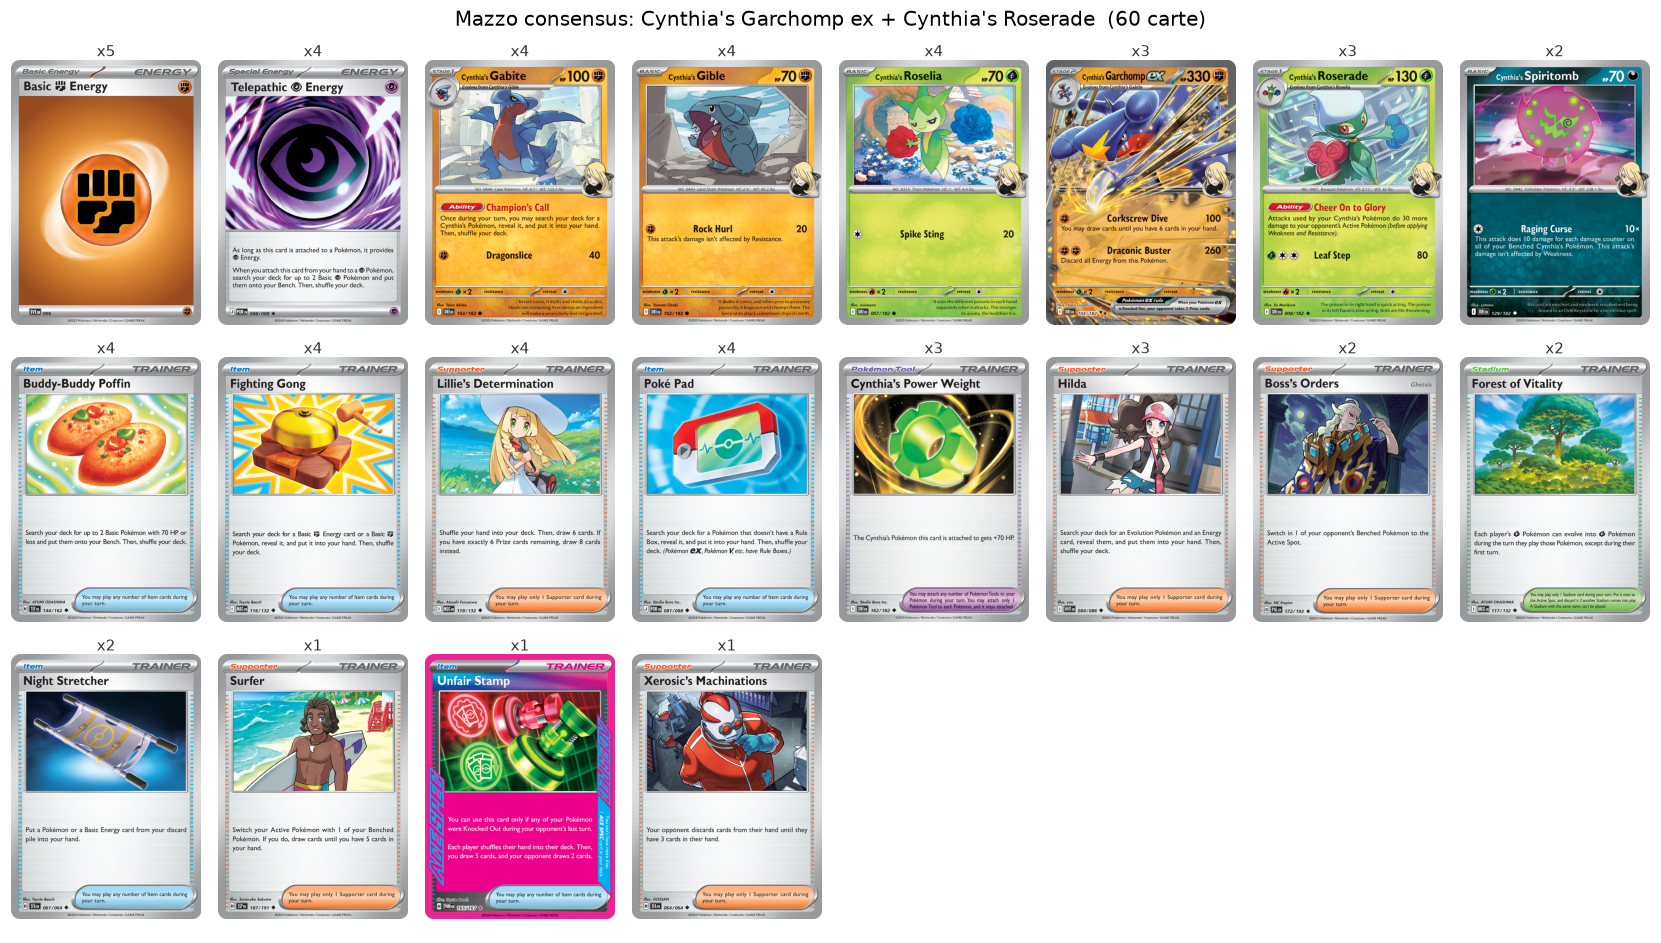

In [21]:
IMG_CACHE_DIR = mu.CACHE_DIR / "card_images"
IMG_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def card_image_url(card_id):
    """Stessa regola di replay_render.py: https://.../tpci/{SET}/{SET}_{NNN}_R_EN.png"""
    if card_id not in pool.index:
        return None
    row = pool.loc[card_id]
    set_code = str(row.get("Expansion") or "").strip().upper()
    no = str(row.get("Collection No.") or "").strip()
    if no.endswith(".0"):
        no = no[:-2]
    if set_code and no.isdigit():
        return f"https://limitlesstcg.nyc3.cdn.digitaloceanspaces.com/tpci/{set_code}/{set_code}_{no.zfill(3)}_R_EN.png"
    return None

def fetch_card_image(card_id):
    url = card_image_url(card_id)
    if url is None:
        return None
    fp = IMG_CACHE_DIR / f"{card_id}.png"
    if fp.exists() and fp.stat().st_size > 0:
        return fp
    try:
        mu.enable_tls(verbose=False)
        req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0 (compatible; PTCG-meta-analysis/1.0)"})
        with urllib.request.urlopen(req, timeout=15) as resp:
            data = resp.read()
        fp.write_bytes(data)
        return fp
    except Exception as exc:
        print(f"  [warn] immagine non disponibile per {CARD_NAME.get(card_id, card_id)}: {exc}")
        return None

def plot_deck_grid(deck, title, filename):
    table = deck_table(deck)
    n = len(table)
    ncols = min(8, n)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(1.9 * ncols, 2.9 * nrows))
    axes = np.atleast_2d(axes)
    for ax in axes.flat:
        ax.axis("off")
    for i, row in table.iterrows():
        ax = axes.flat[i]
        fp = fetch_card_image(int(row["card_id"]))
        ok = False
        if fp is not None:
            try:
                ax.imshow(plt.imread(fp)); ok = True
            except Exception:
                ok = False
        if not ok:
            ax.set_facecolor("#e8e8e8")
            ax.text(0.5, 0.5, row["nome"], ha="center", va="center", wrap=True, fontsize=7)
        ax.set_title(f"x{row['copie']}", fontsize=10, color="#333", pad=2)
    fig.suptitle(f"{title}  ({int(table['copie'].sum())} carte)", fontsize=13)
    save(fig, filename)
    plt.show()

plot_deck_grid(version_b, f"Mazzo consensus: {ARCHETYPE}", f"{slug}_consensus_deck")

---
### Come leggere i risultati

- Con **pochi piloti/partite** per l'archetipo scelto, le percentuali di inclusione (e il winrate)
  hanno margini d'errore ampi: prendi le carte "flex" al confine della soglia con più cautela.
- La build **A** è la scelta più sicura se un pilota forte ha ripetuto la stessa lista molte volte;
  il mazzo **B** è utile quando i piloti convergono sulle stesse carte core ma variano molto sui
  dettagli, e vuoi una lista "di sintesi" pronta da adattare.
- Ricontrolla sempre il mazzo esportato contro le regole ufficiali prima di usarlo in torneo/submission
  (`cg.game.battle_start` rifiuta mazzi non validi — vedi i controlli in `validate_deck`).

## 8. Scheda testuale del mazzo (per far scrivere la logica a un agente)

Il blocco stampato qui sotto riassume in puro testo tutto quello che serve per progettare
l'euristica di un bot su questo mazzo: l'elenco delle carte con le copie, e per ciascuna
HP/Tipo/Debolezza/Resistenza/Ritirata, abilità e attacchi (costo, danno, effetto) — dati letti
riga per riga da `EN_Card_Data.csv` (una riga per mossa/abilità, a differenza di `pool` che le
aggrega). I `Card ID` tra parentesi quadre servono per definire le costanti nel bot, come fa
`agents/gio_v1/main.py`.

Copia il testo (stampato o dal file `.txt` esportato) e incollalo in una chat con un agente di
coding chiedendogli di scrivere `agent(obs_dict) -> list[int]` per questo mazzo — usa
`agents/gio_v1/main.py` o `agents/teo_1/main.py` come esempio dell'interfaccia `cg.api`
(`Observation`, `SelectContext`, `OptionType`, ...).

**Scegli quale versione descrivere** modificando `BRIEF_VERSION` (`"A"` = build esatta più
giocata, `"B"` = mazzo consensus).

In [22]:
# ==== PARAMETRO: quale versione descrivere in dettaglio ====
BRIEF_VERSION = "B"   # "A" = build esatta piu' giocata, "B" = mazzo consensus
# =============================================================

RAW_CARDS = mu.load_cards(CARD_CSV)  # una riga per mossa/abilita' (non aggregata come 'pool')

def card_detail_text(card_id):
    """Statistiche + abilita'/attacchi di una carta, in testo semplice."""
    rows = RAW_CARDS[RAW_CARDS["Card ID"] == card_id]
    if rows.empty:
        return "  (dati carta non trovati)"
    first = rows.iloc[0]
    rule = f" [{first['Rule']}]" if pd.notna(first.get("Rule")) else ""

    def clean_eff(v):
        # il campo puo' contenere newline letterali (piu' paragrafi in una sola cella):
        # li normalizziamo a spazi cosi' ogni riga stampata resta un blocco unico e leggibile.
        if pd.isna(v):
            return ""
        return " ".join(str(v).split())

    lines = []
    if pd.notna(first["HP"]):
        extras = []
        if pd.notna(first["Weakness"]):
            extras.append(f"Debolezza {first['Weakness']}")
        if pd.notna(first["Resistance (Type)"]):
            extras.append(f"Resistenza {first['Resistance (Type)']}")
        if pd.notna(first["Retreat"]):
            extras.append(f"Ritirata {int(first['Retreat'])}")
        extra_txt = f" ({', '.join(extras)})" if extras else ""
        prev = first.get("Previous stage")
        eng_prev = f", evolve da {prev}" if pd.notna(prev) and str(prev).strip() else ""
        lines.append(f"  {first[mu._STAGE_COL]}{eng_prev}, HP {int(first['HP'])}, "
                      f"Tipo {first['Type']}{extra_txt}{rule}")
        for _, r in rows.iterrows():
            mv = r["Move Name"]
            if pd.isna(mv):
                continue
            eff = clean_eff(r["Effect Explanation"])
            if str(mv).startswith("[Ability]"):
                suffix = f": {eff}" if eff else ""
                lines.append(f"  Abilita' {mv.replace('[Ability] ', '')}{suffix}")
            else:
                cost = r["Cost"] if pd.notna(r["Cost"]) else ""
                dmg = f" {r['Damage']} danni" if pd.notna(r["Damage"]) else ""
                suffix = f": {eff}" if eff else ""
                lines.append(f"  Attacco {mv} [{cost}]{dmg}{suffix}")
    else:
        eff = clean_eff(first["Effect Explanation"])
        suffix = f": {eff}" if eff else ""
        lines.append(f"  {first[mu._STAGE_COL]}{rule}{suffix}")
    return "\n".join(lines)

def deck_brief(deck, archetype, version_label):
    table = deck_table(deck)
    total = int(table["copie"].sum())
    lines = [f"DECKLIST POKEMON TCG -- {archetype} (versione: {version_label}, {total} carte)", ""]
    lines.append("Elenco:")
    for _, r in table.iterrows():
        lines.append(f"  x{r['copie']:<2d} [{r['card_id']}] {r['nome']}  ({r['categoria']})")
    lines.append("")
    lines.append("Dettaglio carte (statistiche, abilita', attacchi/effetti):")
    for _, r in table.iterrows():
        lines.append("")
        lines.append(f"[{r['card_id']}] {r['nome']}  x{r['copie']}")
        lines.append(card_detail_text(int(r["card_id"])))
    return "\n".join(lines)

brief_deck = version_a if BRIEF_VERSION == "A" else version_b
brief_label = "A - build esatta piu' giocata" if BRIEF_VERSION == "A" else "B - mazzo consensus"
brief_text = deck_brief(brief_deck, ARCHETYPE, brief_label)
print(brief_text)

brief_path = mu.DATA_DIR / f"05_{slug}_deck_brief.txt"
brief_path.write_text(brief_text, encoding="utf-8")
print(f"\n(salvato anche in {brief_path.relative_to(mu.ROOT)})")

DECKLIST POKEMON TCG -- Cynthia's Garchomp ex + Cynthia's Roserade (versione: B - mazzo consensus, 60 carte)

Elenco:
  x5  [6] Basic {F} Energy  (Energia)
  x4  [20] Rock Fighting Energy  (Energia)
  x4  [380] Cynthia's Gabite  (Pokemon)
  x4  [379] Cynthia's Gible  (Pokemon)
  x4  [341] Cynthia's Roselia  (Pokemon)
  x3  [381] Cynthia's Garchomp ex  (Pokemon)
  x3  [342] Cynthia's Roserade  (Pokemon)
  x2  [387] Cynthia's Spiritomb  (Pokemon)
  x4  [1086] Buddy-Buddy Poffin  (Trainer)
  x4  [1142] Fighting Gong  (Trainer)
  x4  [1227] Lillie's Determination  (Trainer)
  x4  [1152] Poké Pad  (Trainer)
  x3  [1173] Cynthia's Power Weight  (Trainer)
  x3  [1225] Hilda  (Trainer)
  x2  [1182] Boss’s Orders  (Trainer)
  x2  [1261] Forest of Vitality  (Trainer)
  x2  [1097] Night Stretcher  (Trainer)
  x1  [1203] Surfer  (Trainer)
  x1  [1080] Unfair Stamp  (Trainer)
  x1  [1197] Xerosic’s Machinations  (Trainer)

Dettaglio carte (statistiche, abilita', attacchi/effetti):

[6] Basic {F} En